In [1]:
# Standard library
import json
from copy import copy
from math import ceil, isfinite
from pathlib import Path
from time import monotonic
from typing import Any
from itertools import compress

# Math
import numpy as np
from numpy import array, deg2rad, eye, mean, ndarray, pi, set_printoptions, stack, rad2deg, deg2rad
from numpy.random import seed, standard_normal
from scipy.stats import norm, uniform

# Data Handling
import utm
import pandas as pd
from filterpy.monte_carlo import systematic_resample, stratified_resample

# Other Third Party
from rich.progress import track

# Plotting
import matplotlib
from keplergl import KeplerGl
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.transforms import Affine2D
from seaborn import move_legend
from svgpath2mpl import parse_path
from svgpathtools import svg2paths
import seaborn as sns

# ProMis
from promis import ProMis, DeltaStaRMap
from promis.geo import (
    CartesianCollection,
    DeltaGrid,
    CartesianDeltaCollection,
    CartesianLocation,
    CartesianMap,
    CartesianRasterBand,
    PolarCollection,
    PolarLocation,
    BufferedPolarPolygon,
    BufferedPolygon,
)
from promis.loaders import OsmLoader
from promis.logic.spatial import Depth


In [2]:
# This will auto-relead changed ProMis imports
%reload_ext autoreload
%autoreload 2

# The inD Dataset
https://levelxdata.com/ind-dataset/

https://levelxdata.com/wp-content/uploads/2024/03/inD-Format_1_1.pdf

- verschieben der Karte entsprechend der Umgebung
- anpassen der Weite
- für jede situation, (groupby frame?) berechne eine landscape, in der alle agenten verzeichnet sind.
- wir selbst stehen in der Mitte. Unser Heading / speed ist lowkey egal dafür? vielleicht auch hierzu nochmal mit / ohne experimente machen.

In [3]:
data_path = Path(".") / "data" / "inD-dataset-v1.1" / "data"
inD_index = "08"

# setting = f"inD-crossing-{inD_index}"
output_folder = Path(".") / "ground-cofi-exports" / "all"
output_folder.mkdir(exist_ok=True, parents=True)

uam_path = output_folder / "uam"
star_path = output_folder / "star"
promis_path = output_folder / "promis"

for path in [uam_path, star_path, promis_path]:
    path.mkdir(exist_ok=True)


In [4]:
def load_inD_data(inD_index: str):
    metadata = pd.read_csv(data_path / f"{inD_index}_recordingMeta.csv", sep=',')
    car_data = pd.read_csv(data_path / f"{inD_index}_tracks.csv", sep=',')
    car_metadata = pd.read_csv(data_path / f"{inD_index}_tracksMeta.csv", sep=',')
    assert metadata["recordingId"].unique() == car_data["recordingId"].unique() == car_metadata["recordingId"].unique()

    # naive center of the scene, but not our origin of coordinates
    # we use this as a bootstrap
    origin = PolarLocation(
        latitude=metadata["latLocation"][0], longitude=metadata["lonLocation"][0]
    )

    # the dataset uses a local coordinate frame based on the UTM projection.
    # the local frame resembles a CartesianCollection, we just need to transform its origin point
    utm_number = utm.latlon_to_zone_number(origin.latitude, origin.longitude)
    utm_letter = utm.latitude_to_zone_letter(origin.latitude)

    origin_coords = utm.to_latlon(
        easting=metadata["xUtmOrigin"][0],
        northing=metadata["yUtmOrigin"][0],
        zone_number=utm_number,
        zone_letter=utm_letter,
    )
    origin = PolarLocation(longitude=origin_coords[1], latitude=origin_coords[0])

    x_utm = car_data["xCenter"] + metadata["xUtmOrigin"][0]
    y_utm = car_data["yCenter"] + metadata["yUtmOrigin"][0]
    polar_car_coords = np.array(
        [utm.to_latlon(x, y, utm_number, utm_letter) for x,y in zip(x_utm, y_utm)]
    )[:, ::-1] # polar coordinates are parsed longitude first, but the conversion returns coordinates in reverse order
    polar_car_coord_collection = PolarCollection(origin)
    polar_car_coord_collection.append_with_default(polar_car_coords, 0)
    cartesian_car_cords = polar_car_coord_collection.to_cartesian().coordinates()

    car_data["xCenter_utm"] = car_data["xCenter"]
    car_data["yCenter_utm"] = car_data["yCenter"]
    car_data["xCenter"] = cartesian_car_cords[:, 0] 
    car_data["yCenter"] = cartesian_car_cords[:, 1] 

    # we now want to translate the origin to the approximate center of the scene
    # that way, we avoid to compute lots of uninteresting points
    bounds = [[car_data[row].max(), car_data[row].min()] for row in ["xCenter", "yCenter"]]
    offsets = [mean(bound_pair) for bound_pair in bounds]
    diameter = np.ceil( max([bound_pair[0] - bound_pair[1] for bound_pair in bounds]) / 10) * 10

    origin = CartesianLocation(*offsets).to_polar(origin)
    dimensions = width, height = diameter, diameter

    collection = CartesianDeltaCollection(origin=origin, number_of_values=0)
    car_data["xCenter"] = car_data["xCenter"] - offsets[0]
    car_data["yCenter"] = car_data["yCenter"] - offsets[1]
    car_data["speed"] = np.sqrt(np.pow(car_data["xVelocity"], 2) + np.pow(car_data["yVelocity"], 2)) * 3.6
    car_data = car_data.join(car_metadata[["trackId", "class"]], on="trackId", how="left", rsuffix="r", validate="m:1")
    del car_data["trackIdr"]

    collection.append_with_default(car_data[["xCenter", "yCenter", "heading", "speed"]].values, value=())
    dt = 1 / metadata["frameRate"]
    

    return car_data, collection, origin, dimensions, dt

In [5]:
feature_description = {
    "primary": "['highway' = 'primary']",
    "secondary": "['highway' = 'secondary']",
    "tertiary": "['highway' = 'tertiary']",
    "service": "['highway' = 'service']",
    "residential": "['highway' = 'residential']",
    "crossing": "['footway' = 'crossing']",
    "living_street": "[highway=living_street]",
    "unclassified": "['highway' = 'unclassified']",
    "signal": "['highway' = 'traffic_signals']",
}

covariance = {
    "primary": 2 * np.eye(2),
    "secondary": 3 * np.eye(2),
    "tertiary": 3 * np.eye(2),
    "residential": 3 * np.eye(2),
    "living_street": 3 * np.eye(2),
    "service": 4 * np.eye(2),
    "unclassified": 3 * np.eye(2),
}

covariance |= {
    f"left_{key}": covariance[key]
    for key in covariance.keys()
} | {
    f"right_{key}": covariance[key]
    for key in covariance.keys()
}
covariance |= {
    "intersection": 2 * np.eye(2),
    "crossing": 2 * np.eye(2),
    "signal": 2*np.eye(2),

}

general_logic = """
    correct(X, Location) :-
        over(X, Location),
        state_speed(X, S),
        maxspeed(X, Location, MS),
        MS >= S.

    % Definition of a valid mission
    landscape(X) :-
        correct(X, unclassified);
        correct(X, tertiary).
"""

In [6]:


intersection_logic = """
    unclassified_correct(X) :-
        over(X, unclassified),
        state_speed(X, S),
        maxspeed(X, unclassified, MS),
        MS >= S.

    tertiary_correct(X) :-
        over(X, tertiary),
        state_speed(X, S),
        maxspeed(X, tertiary, MS),
        MS >= S.

    % Definition of a valid mission
    landscape(X) :-
        tertiary_correct(X);
        unclassified_correct(X);
        distance(X, intersection) < 10.
"""

In [7]:
road_types = [
    "secondary",
    "tertiary",
    "residential",
    "unclassified",
]

angle_logic = """
    bearing(X) ~ normal(B, 0.001) :- state_bearing(X, B).    

    along(X, LocationType) :- 
       angle(X, LocationType) + bearing(X)   <  90.0,
       angle(X, LocationType) + bearing(X)   > -90.0.

    on_correct_side(X, LocationType) :- 
        along(X, LocationType),
        over(X, right, LocationType);
        not along(X, LocationType),
        over(X, left, LocationType).

    % Definition of a valid mission
    side_correct(X) :-
        on_correct_side(X, secondary);
        on_correct_side(X, tertiary);
        on_correct_side(X, residential);
        on_correct_side(X, unclassified).

    landscape(X) :- distance(X, intersection) >= 10, side_correct(X).
    
    0.5::landscape(X) :- distance(X, intersection) < 10.
    
""" + \
"\n".join([f"""over(X, right, {key}) :- over(X, right_{key}). 
over(X, left, {key}) :- over(X, left_{key}).""" for key in road_types])

angle_logic_requirements = "\n".join([
f"""over(X, left_{key})
over(X, right_{key})
angle(X, {key})
""" for key in road_types
]) + """
distance(X, intersection)
"""

In [8]:
# intersections are unmarked in OSM. As per the wiki, Intersections are represented using shared nodes.
# we therefore use a preprocessor that checks every node with every other node to see wether they are close
def fetch_intersections(
        uam: CartesianMap, 
        number_of_arms = 3, 
        intersection_location_type="intersection", 
        delta = 0.01,
    ) -> list[CartesianLocation]:

    intersection_points: list[CartesianLocation] = []
    for feature_index, feature in enumerate(uam.features):
        if not isinstance(feature, BufferedPolygon): # only buffered ways could be roads that intersect
            continue
        feature_locs = feature.polyline.to_polar().to_cartesian(uam.origin).to_numpy()
        num_close_points = np.zeros(feature_locs.shape[0])
        

        for other_feature_index, other_feature in enumerate(uam.features[feature_index+1:]):
            if not isinstance(other_feature, BufferedPolygon): # only buffered ways could be roads that intersect
                continue
            other_locs = other_feature.polyline.to_polar().to_cartesian(uam.origin).to_numpy()
            feature_mat = np.atleast_3d(feature_locs).repeat(other_locs.shape[0], axis=2)
            other_mat = np.atleast_3d(other_locs).repeat(feature_locs.shape[0], axis=2).transpose((2, 1, 0))
            # mat axes: 0-len(features); 1-2; 2-len(other_features)

            dists = np.sqrt(np.pow(feature_mat-other_mat, 2).sum(axis=1))
            num_close_points += np.sum(dists < delta, axis=1)
            
        new_points = compress(feature.polyline.locations, num_close_points >= number_of_arms - 1)
        intersection_points.extend(
            [new_point for new_point in new_points 
            if not any([new_point.distance(old_point) < delta for old_point in intersection_points])]
        )
    return [CartesianLocation(east=loc.east,
        north=loc.north,
        location_type=intersection_location_type,
        name=loc.name,
        origin=uam.origin,
    ) for loc in intersection_points]

In [9]:
def build_uam(origin, dimensions, inD_index:str, covariance):
    uam = OsmLoader(
        origin=origin,
        dimensions=dimensions,
        feature_description=feature_description,
        polygonize_routes=True,
        timeout=15,
    ).to_cartesian_map()
    uam.features.extend(fetch_intersections(uam))
    uam.apply_covariance(covariance)
    
    uam.save(uam_path / f"uam-{inD_index}.pkl")


In [10]:
def plot_traj_shift(cars):
    fig, ax = plt.subplots(1, 1, figsize=(7,7))
    for feature_index, df in enumerate([cars]):
        for trackId in df["trackId"].unique():
            track = df[df["trackId"] == trackId]
            ax.plot(track["xCenter"], track["yCenter"], alpha = 0.3, color = "red")
            ax.plot(track["xCenter_utm"], track["yCenter_utm"], alpha = 0.3, color = "blue")


In [11]:
def build_star(origin, dimensions, inD_index: str, logic):
    width, height = dimensions
    uam = CartesianMap.load(uam_path / f"uam-{inD_index}.pkl")
    support = DeltaGrid(origin, (50, 50), width, height, speed_res=1, speed_bounds=(35, 55), bearing_res=7)
    dsm = DeltaStaRMap(uam)
    dsm.initialize(support, 15, logic)
    dsm.save(star_path / f"star-{inD_index}.pkl")

In [12]:
def build_landscape(origin, dimensions, logic, logic_name, inD_index):
    width, height = dimensions
    dsm = DeltaStaRMap.load(star_path / f"star-{inD_index}.pkl")
    promis = ProMis(dsm)
    support = DeltaGrid(origin, (50, 50), width, height, speed_res=1, speed_bounds=(35, 55), bearing_res=7)
    promis.solve(support, logic, print_first=False, show_progress=True)
    support.save(promis_path / f"landscape-{inD_index}--{logic_name}.pkl")

## Putting it all together

In [13]:
index_list = [f"0{str(i)}" for i in range(10)] + [str(i) for i in range(10, 32)]

In [14]:
# several trajectory files were recorded on the same intersections
# however, we only want to compute landscapes once per intersection
origin_to_indexes = {}
for index in index_list:
    metadata = pd.read_csv(data_path / f"{index}_recordingMeta.csv", sep=',')
    o_cords = tuple(metadata[["xUtmOrigin", "yUtmOrigin"]].to_numpy()[0])
    mapping = origin_to_indexes.get(o_cords, [])
    mapping.append(index)
    origin_to_indexes[o_cords] = mapping
    
origin_to_indexes

{(np.float64(297631.3187), np.float64(5629917.34465)): ['00',
  '01',
  '02',
  '03',
  '04',
  '05',
  '06'],
 (np.float64(293487.1224), np.float64(5629711.58163)): ['07',
  '08',
  '09',
  '10',
  '11',
  '12',
  '13',
  '14',
  '15',
  '16',
  '17'],
 (np.float64(295620.9575), np.float64(5628102.04258)): ['18',
  '19',
  '20',
  '21',
  '22',
  '23',
  '24',
  '25',
  '26',
  '27',
  '28',
  '29'],
 (np.float64(300127.0853), np.float64(5629091.0587)): ['30', '31']}

In [15]:
group00 = index_list[:7]
group07 = index_list[7:18]
group18 = index_list[18:30]
group30 = index_list[30:]

used_index = {i: "00" for i in group00} \
    | {i: "07" for i in group07} \
    | {i: "18" for i in group18} \
    | {i: "30" for i in group30}

index_shortlist = ["00", "07", "18", "30"]

In [16]:
dimensions_per_index = {}
for index in index_shortlist:
    _, _, _, dimensions, _ = load_inD_data(index)
    dimensions_per_index[index] = dimensions
dimensions_per_index

{'00': (np.float64(130.0), np.float64(130.0)),
 '07': (np.float64(70.0), np.float64(70.0)),
 '18': (np.float64(90.0), np.float64(90.0)),
 '30': (np.float64(90.0), np.float64(90.0))}

In [17]:
#specs = {}
for inD_index in index_shortlist:
    _, _, origin, dimensions, dt = load_inD_data(inD_index)
    build_uam(origin, dimensions, inD_index, covariance)
    #specs[inD_index] = (origin, dimensions, dt)

OSM query failed, sleeping 15.000000s...
OSM query failed, sleeping 15.000000s...
OSM query failed, sleeping 15.000000s...
OSM query failed, sleeping 15.000000s...


KeyboardInterrupt: 

In [32]:
logic = angle_logic
logic_name = "sides"
logic_requirements = angle_logic_requirements

In [ ]:

for inD_index in index_shortlist:
    uam = CartesianMap.load(uam_path / f"uam-{inD_index}.pkl")
    origin, dimensions = uam.origin, dimensions_per_index[inD_index]
    build_star(origin, dimensions, inD_index, logic_requirements)

In [ ]:

for inD_index in index_shortlist[:]:
    uam = CartesianMap.load(uam_path / f"uam-{inD_index}.pkl")
    origin, dimensions = uam.origin, dimensions_per_index[inD_index]
    build_landscape(origin, dimensions, logic, logic_name, inD_index)

[0.         0.26666671 0.06666668 0.93333328 0.60000002 0.13333336
 1.         0.73333335 0.33333337 0.79999995 0.46666664 0.19999999
 0.53333342 0.66666675 0.39999998 0.86666673 0.01       0.8593334
 0.58600003 0.36666667 0.29600003 0.04       0.98000002 0.75999999
 0.56600004 0.52266669 0.41999999 0.12733334 0.59600002 0.67399997
 0.53466666 0.5        0.54333329 0.14466667 0.28066668 0.49533337
 0.56999993 0.07       0.46533334 0.67600006 0.33000001 0.51199996
 0.76866668 0.92466658 0.02       0.23999999 0.50933337 0.49400002
 0.472      0.18000001 0.41       0.54333335 0.54666674 0.2
 0.03       0.1        0.81199998 0.70533341 0.09266667 0.30066666
 0.38       0.40000001 0.44799998 0.31999999 0.13       0.79399991
 0.52199996 0.47666663 0.95999998 0.15000001 0.93000001 0.54000002
 0.50999999 0.20999999 0.78199995 0.66466665 0.50200003 0.36466664
 0.07533334 0.33666667 0.59000003 0.50866669 0.75199997 0.44
 0.51999998 0.53733331 0.54911113 0.75666672 0.18799999 0.80066663
 0.755733

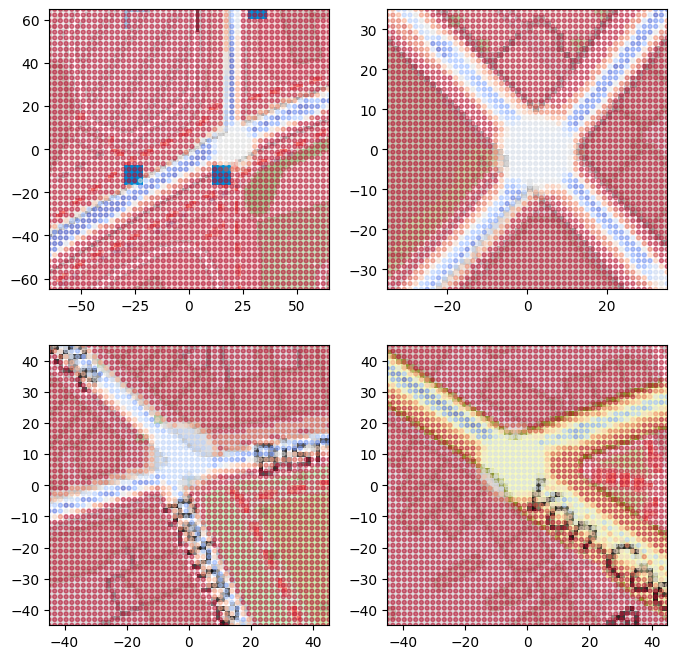

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
b = 180
s = 30
for i, inD_index in enumerate(index_shortlist):
    landscape = CartesianDeltaCollection.load(promis_path / f"landscape-{inD_index}--{logic_name}.pkl") 
    print(landscape.data["v0"].unique())
    landscape.scatter(bearing=b, speed=s, s=8, alpha = 0.5, ax = axes[int(i / 2)][i % 2], cmap = "coolwarm_r")

[BufferedCartesianPolygon(locations=[CartesianLocation(east=48.230688009416966, north=49.83464708796229, origin=PolarLocation(latitude=50.782065239207384, longitude=6.071154247841292, identifier=2152656385682894359), location_type=tertiary, identifier=3736249729021123638), CartesianLocation(east=48.13360005655547, north=49.70697544624547, origin=PolarLocation(latitude=50.782065239207384, longitude=6.071154247841292, identifier=2152656385682894359), location_type=tertiary, identifier=3442700854859804814), CartesianLocation(east=38.21289141725606, north=37.190156800202196, origin=PolarLocation(latitude=50.782065239207384, longitude=6.071154247841292, identifier=2152656385682894359), location_type=tertiary, identifier=349622934049855101), CartesianLocation(east=17.543796757556816, north=10.40090819805904, origin=PolarLocation(latitude=50.782065239207384, longitude=6.071154247841292, identifier=2152656385682894359), location_type=tertiary, identifier=837097273381261388), CartesianLocation(

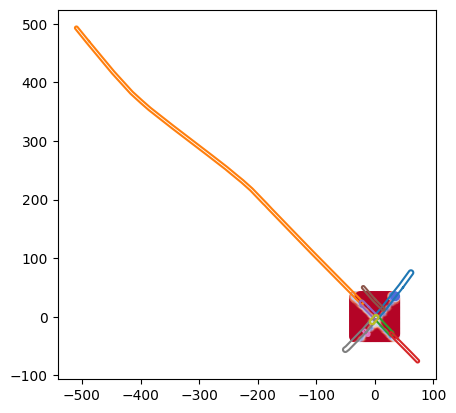

In [34]:
i = "07"
dsm = DeltaStaRMap.load(star_path / f"star-{i}.pkl")
uam = CartesianMap.load(uam_path / f"uam-{i}.pkl")
landscape = CartesianDeltaCollection.load(promis_path / f"landscape-{i}--sides.pkl")

landscape.scatter(bearing=180, speed = 40, cmap="coolwarm_r")


print(uam.features)
for f in uam.features:
    if not isinstance(f, BufferedPolygon):
        continue
    plt.plot(*f.geometry.exterior.xy)
    print(f.name, calculate_street_width(f.polyline), f.location_type)

add an any location type, 
left_side, right_side? das könnte es eleganter machen

## Track Preprocessing

In [35]:
env_index = "00"
group = group00

support = CartesianDeltaCollection.load(promis_path / f"landscape-{env_index}--sides.pkl")

In [36]:


#training_set = pd.DataFrame()
validation_set = pd.DataFrame()
test_set = pd.DataFrame()

for inD_index in group:
    tracks, _, _, _, _ = load_inD_data(inD_index)
    tracks["group"] = inD_index

    ids = tracks["trackId"].unique()

    val_start_i, test_start_i = int(0.0 * len(ids)), int(0.5 * len(ids))
    # training_part = data[:val_start_i]
    validation_part = ids[val_start_i:test_start_i]
    test_part = ids[test_start_i:]

    # training_set = pd.concat([training_set, tracks[tracks["trackId"].isin(training_part)]], ignore_index=True)
    validation_set = pd.concat([validation_set, tracks[tracks["trackId"].isin(validation_part)]], ignore_index=True)
    test_set = pd.concat([test_set, tracks[tracks["trackId"].isin(test_part)]], ignore_index=True)

In [37]:
print(len(validation_set), len(test_set))
# print(training_set["class"].unique())
print(validation_set["class"].unique())
print(test_set["class"].unique())


861388 419640
['car' 'truck_bus' 'bicycle' 'pedestrian']
['car' 'pedestrian' 'truck_bus' 'bicycle']


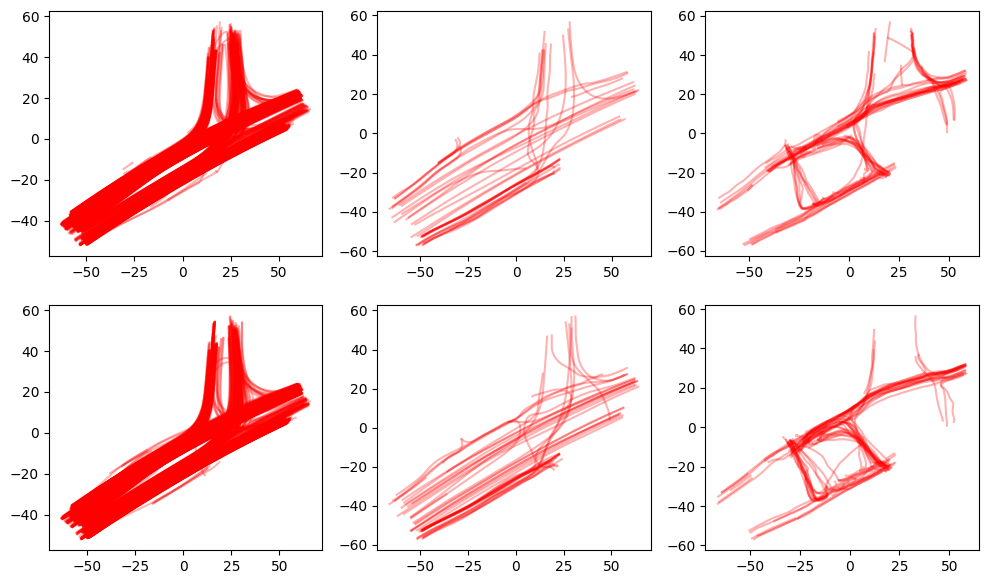

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

agent_type_list = [['car', 'truck_bus'], ['bicycle'], ['pedestrian']]
disambiguition = [
    [track_set[track_set["class"].isin(agent_types)] for agent_types in agent_type_list]
    for track_set in [validation_set, test_set] 
]

for i, tracksets in enumerate(disambiguition):
    for j, trackset in enumerate(tracksets):
        ids = trackset["trackId"].unique()
        for ref_group in group:
            group_tracks = trackset[trackset["group"] == ref_group]
            for trackId in ids:
                track = group_tracks[group_tracks["trackId"] == trackId]
                axes[i][j].plot(track["xCenter"], track["yCenter"], alpha = 0.3, color = "red")

## Experiments

In [103]:
    
def experiment1(
    vehicle_df: pd.DataFrame,
    width, height,
    seed_value: int = 2024,
    constitutional_trust: float = 0.8,
    interpolator: Any | None = None,
    N: int = 2500,
    dt: float = 1/25,
    sensor_std_error = 1,
    process_noise = array([30, 20]),
):
    def create_initial_particles(N: int) -> ndarray:
        return np.stack(
            [
                uniform(loc=-width / 2, scale=width).rvs(N),  # x position (east)
                uniform(loc=-height / 2, scale=height).rvs(N),  # y position (north)
                uniform(loc=0, scale=2 * pi).rvs(N),  # heading
                norm(loc=40, scale=10).rvs(N),  # speed
            ]
        ).T
    
    def predict(particles, dt, process_noise):
        """move according to control input u (heading change, velocity)
        with noise Q (std heading change, std velocity)`"""

        scaled_noise = process_noise * dt
        
        particles = particles.copy()
        N = len(particles)

        # We first add noise to the heading
        particles[:, 2] += deg2rad(
            scaled_noise[0] * standard_normal(N)  # we can turn 90 degrees per second in each direction (95% interval) # but this is per time step? = 1/25th sec
        )
        particles[:, 2] %= 2 * pi

        # Add noise to the speed
        particles[:, 3] += scaled_noise[1]  * standard_normal(N) # pm 40 kmh 

        # Compute the actual distance we travel
        distance = particles[:, 3] * dt / 3.6 # to scale to m/s
        particles[:, 0] += np.cos(particles[:, 2]) * distance
        particles[:, 1] += np.sin(particles[:, 2]) * distance

        return particles
    

    def update(
        particles,
        weights,
        z,
        R,
        dt,
        constitutional_trust: float = constitutional_trust,
    ):
        weights = weights.copy()

        positions = particles[:, :2]
        distance = np.linalg.norm(positions - z, axis=1)

        # Evaluate an RBF kernel
        if dt > 0.01:
            weights *= norm.pdf(distance, 0, R) # remove dt

        if constitutional_trust > 0:
            this_interpolator = interpolator
            constitution = this_interpolator(particles)[:, 0]
            weight_change = constitutional_trust * constitution + (1 - constitutional_trust)
            # Disallow going to placed where the constitution is not even defined
            weight_change[~np.isfinite(constitution)] = 0
            weights *= weight_change

        weights += 1.0e-300  # avoid round-off to zero
        weights /= sum(weights)  # normalize

        return weights
    

    def estimate(particles, weights):
        """returns mean and variance of the weighted particles"""

        mean = np.average(particles, weights=weights, axis=0)
        var = np.average((particles - mean) ** 2, weights=weights, axis=0)
        return mean, var

    def neff(weights):
        return 1.0 / np.sum(np.square(weights))

    def resample_from_index(particles, weights, indexes):
        particles[:] = particles[indexes]
        weights.resize(len(particles))
        weights.fill(1.0 / len(weights))

    def run_pf1(
        N: int,
        data: np.ndarray,
        sensor_std_err,
        process_noise,
        do_plot=False,
        plot_particles=True,
        plot_every=3,
        dt=dt,
    ):
        if do_plot:
            plt.figure()

        # Create particles uniformly over the entire space
        particles = create_initial_particles(N)

        # However, for the location we can do a bit better by assuming that the current
        # observation is approximately correct
        particles[:, 0] = norm(loc=data[0, 0], scale=10).rvs(N)
        particles[:, 1] = norm(loc=data[0, 1], scale=10).rvs(N)

        # create weights
        weights = np.ones(N) / N

        if do_plot and plot_particles:
            alpha = 0.20
            if N > 5000:
                alpha *= np.sqrt(5000) / np.sqrt(N)
            plt.scatter(particles[:, 0], particles[:, 1], alpha=alpha, color="g")
            plt.show()

        weights_trace = []
        particle_trace = []
        xs = []
        for i, obs in enumerate(data):
            dt = obs[4]
            # move
            particles = predict(particles, dt=dt, process_noise=process_noise)

            # incorporate measurements
            weights = update(particles, weights, z=obs[:2], R=sensor_std_err, dt=dt)

            # resample if too few effective particles
            if neff(weights) < N / 2:
                # print("resample")
                indexes = stratified_resample(weights)
                resample_from_index(particles, weights, indexes)
                assert np.allclose(weights, 1 / N)
            else:
                # print("don't resample")
                pass

            mu, var = estimate(particles, weights)
            xs.append(mu)

            weights_trace.append(weights.copy())
            particle_trace.append(particles.copy())

            if do_plot and i % plot_every == 0:
                if plot_particles:
                    # top 10 percent of weights
                    percentile = 80
                    top_10_weight_val = np.percentile(weights, percentile)
                    print(top_10_weight_val, weights.max())
                    boosted_heaviest = np.where(weights >= top_10_weight_val, weights, 0)

                    plt.scatter(particles[:, 0], particles[:, 1], alpha= 1 * boosted_heaviest, color="g")
                # draw a cricle perimeter at 1 std
                plt.gca().add_artist(
                    plt.Circle((mu[0], mu[1]), radius=sensor_std_err, fill=False)
                )
                p1 = plt.scatter(obs[0], obs[1], marker="x", color="r")
                p2 = plt.scatter(mu[0], mu[1], marker="s", color="b")
                plt.xlim(-width / 2, width / 2)
                plt.ylim(-height / 2, height / 2)
                plt.show()

        xs = np.array(xs)
        if do_plot:
            plt.legend([p1, p2], ["Actual", "PF"], loc=4, numpoints=1)
            plt.show()

        pos_error = np.linalg.norm(xs[:, :2] - data[:, :2], axis=1)
        all_error = np.linalg.norm(xs[:, :] - data[:, :4], axis=1)

        if do_plot:
            plt.show()

        return {
            "particles": array(particle_trace),
            "weights": array(weights_trace),
            "estimates": xs,
            "pos_error": pos_error,
            "pos_error_mean": pos_error.mean(),
            "all_error": all_error,
            "all_error_mean": all_error.mean(),
            "truth": data,
        }


    ground_truth = stack(
        (
            vehicle_df["xCenter"],
            vehicle_df["yCenter"],
            deg2rad(vehicle_df["heading"]),
            vehicle_df["speed"],
            np.repeat(dt, len(vehicle_df))
        )
    ).T

    seed(seed_value)
    return run_pf1(
        N=N,
        data=ground_truth,
        sensor_std_err=sensor_std_error,
        process_noise=process_noise,
        do_plot=False,
        plot_every=6,
        dt=dt,
    )

dt = 1 / 25
trackId = 12
take_every = 25
df = validation_set[validation_set["group"] == group[0]]

compare = [experiment1(
    df[df["trackId"] == trackId][::take_every],
    width = dimensions_per_index[env_index][0],
    height = dimensions_per_index[env_index][1],
    seed_value=2025,
    constitutional_trust=trust_ratio,
    interpolator=support.get_interpolator(),
    dt=dt * take_every,
    process_noise=array([60, 40]),
    sensor_std_error=1,
    N=2500
) for trust_ratio in [0, 0.5, 1]]


res_specific = compare[1]


[0.11786177 0.08499501 0.17533931 0.22059222 0.22665335 0.21983629
 0.28424072 0.31142442 0.22749745 0.25892436]
[0.11786177 0.08499501 0.17533931 0.20636359 0.18538973 0.26072965
 0.29079723 0.25951086 0.09472238 0.09674684]
[5.73413835 6.23314692 3.82692529 1.21627876 0.4548911  0.69569431
 0.7072243  0.53582586 0.55410271 0.11088736]


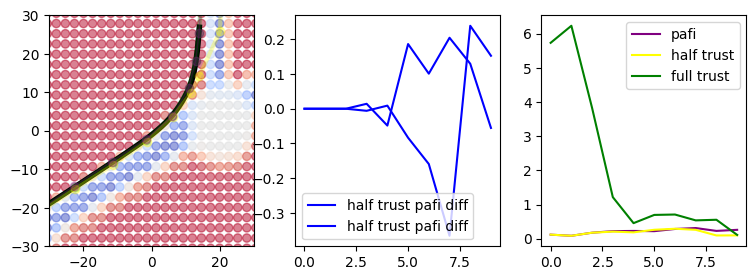

In [107]:
fig, axes = plt.subplots(1,3, figsize=(9,3))
axes[0].set_xlim(-30, 30)
axes[0].set_ylim(-30, 30)

plot = support.scatter(bearing = 270, speed = 40, plot_basemap=False, alpha=0.5, cmap = "coolwarm_r", ax = axes[0])
track = df[df["trackId"] == trackId]
axes[0].plot(track["xCenter"][20:], track["yCenter"][20:], linewidth=4, color="black", label="ground truth")

estimates1 = compare[1]["estimates"]
axes[0].plot(estimates1[:, 0], estimates1[:, 1], "o-", linewidth=3, alpha=0.3, color="green", label="trust 0.5")
estimates2 = compare[2]["estimates"]
axes[0].plot(estimates2[:, 0], estimates2[:, 1], "o-", linewidth=3, alpha=0.3, color="yellow", label="trust 1 - cofi")
pafi = compare[0]["estimates"]
axes[0].plot(pafi[:, 0], pafi[:, 1], "o-", linewidth=1, alpha=0.3, color="purple", label="particle filter")

x = np.arange(len(pafi))

d1 = pafi[:, :2] - estimates1[:, :2] # np.linalg.norm(, axis=1 )
# d2 = np.linalg.norm(pafi[:, :2] - estimates2[:, :2], axis=1)
axes[1].plot(x, d1, c="b", label="half trust pafi diff")
# axes[1].plot(x, d2, c="r", label="full trust pafi diff")

for i, (label, color) in enumerate(zip(["pafi", "half trust", "full trust"], ["purple", "yellow", "green"])):
    data = compare[i]["pos_error"]
    print(data)
    axes[2].plot(x, data, c=color, label=label)  

#axes[0].legend()
axes[1].legend()
axes[2].legend()
pass

In [105]:
estimates = res_specific["estimates"][:, :2]
truth = res_specific["truth"]
len(estimates), len(truth)
for i in range(3):
    print (compare[i]["pos_error_mean"])


0.21273648949582497
0.17724563532906154
2.006911496580926


### Experiment
Now that a single example runs through, it is time to evaluate the performance of a particle filter both with our constitution and without it. What split to use?



In [ ]:
by_frames = car_data.groupby("frame").count()
max_agents = by_frames["trackId"].max() + 1
agents_per_frame = [len(by_frames[by_frames["trackId"] == i]) for i in range(max_agents)]
ax = plt.subplot()
ax.bar(np.arange(max_agents), agents_per_frame)
ax.set_title(f"number of agents per frame in inD scenario {inD_index}")
ax.set_xlabel("number of agents")

In [46]:
from operator import itemgetter

In [ ]:
def evaluate_trust_ratio(data: pd.DataFrame, N: int, sample_every: int):
    trust_partitions = 4
    interpolator = support.get_interpolator()

    group_parts = [data[data["group"] == group_index] for group_index in group]
    
    return np.concatenate([
        stack([
            np.array(
                [itemgetter("pos_error_mean", "all_error_mean")(experiment1(
                    part[part["trackId"] == trackId][::sample_every],
                    width = dimensions_per_index[env_index][0],
                    height = dimensions_per_index[env_index][1],
                    seed_value=2026,
                    constitutional_trust=trust,
                    interpolator=interpolator,
                    N=N,
                    dt=sample_every*dt
                )) for trust in np.arange(trust_partitions + 1) / trust_partitions]
            ) for trackId in part["trackId"].unique()]
        )
    for part in group_parts], axis=0)

Ns = [1000, 2000, 5000] # [100, 250, 500, 1000, 1500]
for_n = []

car_data = disambiguition[0][0]

for n in Ns:
    for_n.append(evaluate_trust_ratio(car_data, N=n, sample_every=24))

In [ ]:
from itertools import product

process_noise_v = np.arange(10, 101, 10)
process_noise_b = np.arange(10, 101, 10)
ns = np.array([1000, 2000, 4000])
sampling_rates = np.array([12, 18, 25, 37])

grid_search_results = []


interpolator = support.get_interpolator()
data = validation_set
group_parts = [data[data["group"] == group_index] for group_index in group]
trust = 0.5
sensor_std_error = 1

for v, b, n, sample_rate in product([30], [30], [100], [25]):#process_noise_v, process_noise_v, ns, sampling_rates):
    grid_search_results.append(
        [v, b, n, sample_rate, sensor_std_error, trust, *np.mean(    
            np.concatenate([
                np.array(
                    [itemgetter("pos_error_mean", "all_error_mean")(experiment1(
                        part[part["trackId"] == trackId][::sample_rate],
                        width = dimensions_per_index[env_index][0],
                        height = dimensions_per_index[env_index][1],
                        seed_value=2026,
                        constitutional_trust=trust,
                        interpolator=interpolator,
                        N=n,
                        process_noise=array([v, b]),
                        sensor_std_error = sensor_std_error,
                        dt=sample_rate*dt
                )) for trackId in part["trackId"].unique()[::3]])
            for part in group_parts], axis=0),
        axis=0)
    ])

grid_search_results = pd.DataFrame(array(grid_search_results), 
    columns=["v_noise", "b_noise", "n", "rate", "std_err", "trust", "pos_error_mean", "all_error_mean"])


ValueError: Shape of passed values is (1, 8), indices imply (1, 6)

N = 1000
(array([581, 350, 103,  19,   5]), array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5]))
[0.17939973 0.18329547 0.19942101 0.24665969 0.72786567]
N = 2000
(array([601, 351,  89,  14,   3]), array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5]))
[0.15598594 0.16004985 0.17711713 0.22289172 0.70306008]
N = 5000
(array([682, 338,  33,   5,   0]), array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5]))
[0.12400003 0.12856821 0.14913654 0.19925149 0.68366307]


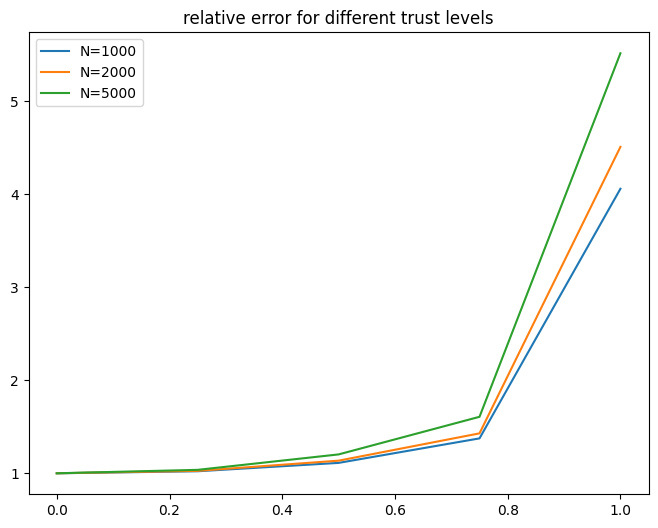

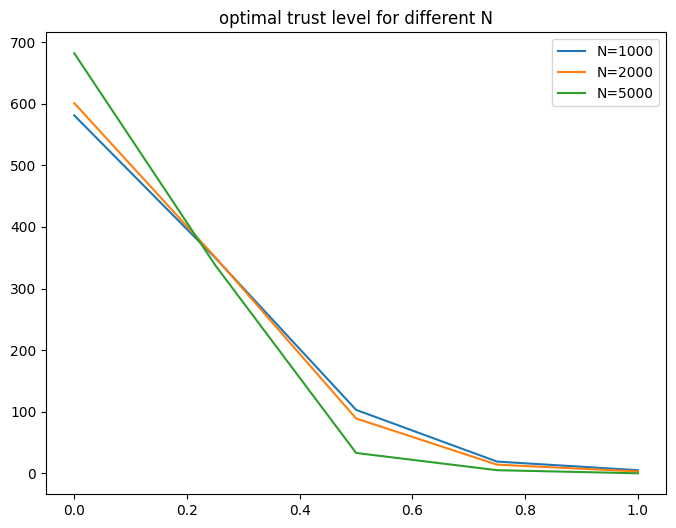

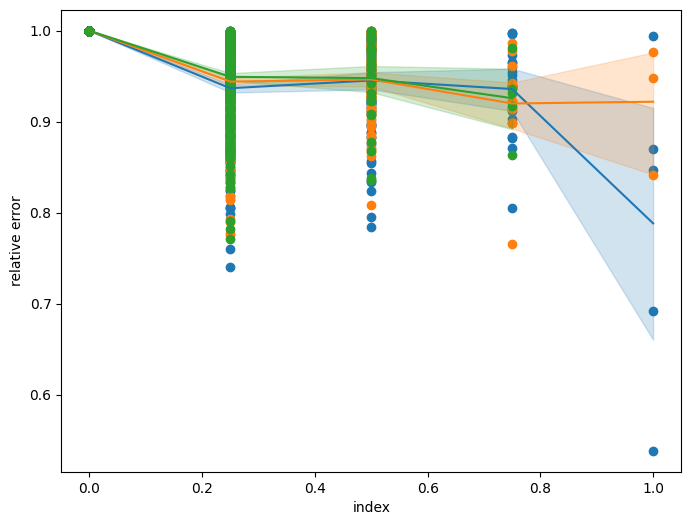

In [48]:
fig, ax = plt.subplots(figsize=(8,6))
big, bx = plt.subplots(figsize=(8,6))
cig, cx = plt.subplots(figsize=(8,6))

for n, data in zip(Ns, for_n):
    print(f"N = {n}")
    print(np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5))
    print(data[:, :, 0].mean(axis = 0))

    ax.plot(np.arange(data.shape[1]) / (data.shape[1]-1), data[:, :, 0].mean(axis = 0) / data[:, :, 0].mean(axis = 0)[0], label=f"N={n}")
    bx.plot(np.arange(data.shape[1]) / (data.shape[1]-1), np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5)[0], label=f"N={n}")
    
    index_min = pd.DataFrame({
        "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1), 
        "relative error": data[:, :, 0].min(axis=1) / data[:, 0, 0],
    })
    cx.scatter(index_min["index"], index_min["relative error"])
    
    sns.lineplot(data=index_min, x="index", y="relative error", ax=cx)


    
ax.set_title("relative error for different trust levels")
ax.legend()

bx.set_title("optimal trust level for different N")
bx.legend()

In [51]:
data = car_data
group_parts = [data[data["group"] == group_index] for group_index in group]
sum([len(part["trackId"].unique()) for part in group_parts])

1058

In [ ]:
def analyze_divergence(id_set: ndarray, N: int, sample_every: int):
    ax = plt.subplot()
    support.scatter(bearing = 320, speed = 30, ax=ax, alpha=0.5, cmap="coolwarm_r")
    interpolator = support.get_interpolator()
    trust = 0.9
    for trackId in id_set:
        res = experiment1(
            car_data[car_data["trackId"] == trackId][::sample_every],
            seed_value=2026,
            constitutional_trust=trust,
            interpolator=interpolator,
            N=N,
            dt=sample_every*dt
        )
        error, pos = res["pos_error"], res["estimates"]
        hi_error = np.quantile(error, 0.95)
        hi_error_pos = pos[error >= hi_error, :]
        ax.scatter(hi_error_pos[:, 0], hi_error_pos[:, 1], alpha=0.9, c=plt.cm.viridis(trackId / 140))
    
analyze_divergence(training_set, 1000, 25)

trust ratio als Maß der Validität der Logik

In [ ]:
data = trust_levels_validation[::, :, :]
buckets = np.arange(11) / 10
fig, ax = plt.subplots(figsize=(8,8))
for i in range(data.shape[0]):
    ax.plot(buckets, data[i, :, 0], alpha = 0.2, c="b")

np.divide(data[data.argmin(axis=1), ], )

In [ ]:
cmap = matplotlib.colormaps["viridis"]
fig, ax = plt.subplots(1,1, figsize=(7, 5))
buckets = np.arange(11) / 10
for downsample in trust_levels_validation.keys():
    data = trust_levels_validation[downsample]
    rate = downsample * dt * 2
    errors = [data[bucket][0] / data[buckets[0]][0] for bucket in buckets]
    ax.plot(buckets, errors, "o-", label=f"{rate}s steps", c=cmap(rate))

plt.legend()
        

copied results with 2026 seed and 2500 particles

```
{np.float64(0.0): array([ 0.0807211 , 55.01982065]),
 np.float64(0.1): array([1.10506074e-01, 1.14607972e+02]),
 np.float64(0.2): array([  0.11310969, 106.6030014 ]),
 np.float64(0.3): array([  0.11146027, 105.06603337]),
 np.float64(0.4): array([  0.11252331, 104.55776024]),
 np.float64(0.5): array([  0.11184959, 104.65238935]),
 np.float64(0.6): array([  0.11119495, 104.58168528]),
 np.float64(0.7): array([  0.1120396 , 104.63279747]),
 np.float64(0.8): array([  0.11167167, 104.76305301]),
 np.float64(0.9): array([  0.1109582 , 104.56865198]),
 np.float64(1.0): array([  0.18037394, 106.56815634])}
```

Particles, system_error and street width would be hyper-parameters to tune?

Performance is bad because of the street width. Uncertain, to what extent i should change my models, as part might stem from the uncertainty. 
